In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import xgboost as xgb
import json
import yaml
import hashlib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows, feature_config_hash_text
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.models.xgb_train import train_xgboost
from src.models.lgbm_train import train_lightgbm
from src.models.catboost_train import train_catboost
from src.models.ensemble import create_ensemble
from src.eval.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from src.eval.evaluate import print_metrics_summary
from src.eval.calibration import fit_calibrator_from_df

paths = load_paths()
logger = setup_logger(level="INFO")


In [2]:
features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

logger.info("Re-extracting VNAT features...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat"

vnat_old = pd.read_parquet(paths.data_processed / "vnat" / "features_trainable.parquet")
split_map = dict(zip(vnat_old["capture_id"], vnat_old["split"]))
vnat_feats["split"] = vnat_feats["capture_id"].map(split_map).fillna("unknown")
vnat_feats = vnat_feats[vnat_feats["split"] != "unknown"].copy()
vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()

logger.info("Re-extracting ISCX features...")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

iscx_old = pd.read_parquet(paths.data_processed / "iscx" / "features.parquet")
split_map_iscx = dict(zip(iscx_old["capture_id"], iscx_old["split"]))
iscx_feats["split"] = iscx_feats["capture_id"].map(split_map_iscx).fillna("unknown")
iscx_feats = iscx_feats[iscx_feats["split"] != "unknown"].copy()
iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()

df_all = pd.concat([vnat_feats, iscx_feats], ignore_index=True)
df_all["split"] = df_all["split"].replace({"iscx_train": "train", "iscx_val": "val", "iscx_test": "test"})

logger.info("Rebalancing VNAT splits for robust evaluation...")
vnat_mask = df_all["dataset"] == "vnat"
vnat_df = df_all[vnat_mask].copy()
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss.split(vnat_df, groups=vnat_df["capture_id"]))
vnat_train = vnat_df.iloc[train_idx]
vnat_temp = vnat_df.iloc[temp_idx]
gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val_test.split(vnat_temp, groups=vnat_temp["capture_id"]))
vnat_val = vnat_temp.iloc[val_idx]
vnat_test = vnat_temp.iloc[test_idx]
vnat_train["split"], vnat_val["split"], vnat_test["split"] = "train", "val", "test"
vnat_balanced = pd.concat([vnat_train, vnat_val, vnat_test])
df_all = pd.concat([df_all[~vnat_mask], vnat_balanced], ignore_index=True)

vb_train_cap = "vpn_vpn_voipbuster1a.pcap"
vb_test_cap = "vpn_vpn_voipbuster1b.pcap"
logger.info(f"Enforcing Voipbuster splits: {vb_train_cap} -> TRAIN, {vb_test_cap} -> TEST")
df_all.loc[df_all["capture_id"] == vb_train_cap, "split"] = "train"
df_all.loc[df_all["capture_id"] == vb_test_cap, "split"] = "test"

print("Final splits after rebalancing:\n", df_all["split"].value_counts())

logger.info("Fitting and saving new FeaturePipeline...")
pipeline = FeaturePipeline().fit(df_all[df_all["split"] == "train"])
feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline.save(feature_art, feature_config_hash=feature_config_hash_text(features_yaml))
logger.info(f"Pipeline saved. Model features: {len(pipeline.model_feature_names())}")

2026-02-27 21:58:53 | INFO | ai-vpn-firewall | Re-extracting VNAT features...
2026-02-27 21:59:24 | INFO | ai-vpn-firewall | Re-extracting ISCX features...
2026-02-27 21:59:47 | INFO | ai-vpn-firewall | Rebalancing VNAT splits for robust evaluation...
2026-02-27 21:59:47 | INFO | ai-vpn-firewall | Enforcing Voipbuster splits: vpn_vpn_voipbuster1a.pcap -> TRAIN, vpn_vpn_voipbuster1b.pcap -> TEST
Final splits after rebalancing:
 split
train    9428
val      2423
test     1138
Name: count, dtype: int64
2026-02-27 21:59:47 | INFO | ai-vpn-firewall | Fitting and saving new FeaturePipeline...
2026-02-27 21:59:48 | INFO | ai-vpn-firewall | Pipeline saved. Model features: 55


In [3]:
# 2. Train Individual Models
logger.info("\n" + "="*60 + "\nTraining XGBoost...")
xgb_res = train_xgboost(paths=paths, xgb_yaml=paths.configs_dir / "xgb.yaml", df=df_all)
print_metrics_summary(xgb_res.metrics)

logger.info("\n" + "="*60 + "\nTraining LightGBM...")
lgbm_res = train_lightgbm(paths=paths, lgbm_yaml=paths.configs_dir / "lgbm.yaml", df=df_all)
print_metrics_summary(lgbm_res.metrics)

logger.info("\n" + "="*60 + "\nTraining CatBoost...")
cat_res = train_catboost(paths=paths, catboost_yaml=paths.configs_dir / "catboost.yaml", df=df_all)
print_metrics_summary(cat_res.metrics)


2026-02-27 21:59:48 | INFO | ai-vpn-firewall | 
Training XGBoost...
DEBUG mean/std (first 5):
[-0.  0. -0. -0. -0.]
[1. 1. 1. 1. 1.]
[0]	train-logloss:0.65434	train-auc:0.97383	train-aucpr:0.92546	val-logloss:0.67195	val-auc:0.86033	val-aucpr:0.75030
[100]	train-logloss:0.07492	train-auc:0.99865	train-aucpr:0.99663	val-logloss:0.26257	val-auc:0.98791	val-aucpr:0.97736
[200]	train-logloss:0.03879	train-auc:0.99967	train-aucpr:0.99906	val-logloss:0.19233	val-auc:0.99305	val-aucpr:0.98717
[300]	train-logloss:0.02360	train-auc:0.99991	train-aucpr:0.99973	val-logloss:0.15167	val-auc:0.99528	val-aucpr:0.99090
[400]	train-logloss:0.01649	train-auc:0.99996	train-aucpr:0.99989	val-logloss:0.13869	val-auc:0.99574	val-aucpr:0.99159
[500]	train-logloss:0.01239	train-auc:0.99999	train-aucpr:0.99996	val-logloss:0.12961	val-auc:0.99608	val-aucpr:0.99227
[600]	train-logloss:0.00991	train-auc:0.99999	train-aucpr:0.99998	val-logloss:0.12070	val-auc:0.99648	val-aucpr:0.99300
[700]	train-logloss:0.00820	t

In [4]:
logger.info("\n" + "="*60 + "\nCreating and Evaluating Ensemble...")
ens_res = create_ensemble(paths=paths, ensemble_yaml=paths.configs_dir / "ensemble.yaml")
print_metrics_summary(ens_res.metrics)

# NOTE: Calibration is now handled INSIDE create_ensemble, so we don't need to do it again here.
# We just load the already-calibrated predictions for the final report.
df_ens_preds = pd.read_parquet(ens_res.preds_path)


2026-02-27 22:00:16 | INFO | ai-vpn-firewall | 
Creating and Evaluating Ensemble...
Optimal Weights:
  - xgb: 0.3333
  - lgbm: 0.3333
  - catboost: 0.3333
Calibrating ensemble probabilities (internal step)...

EVALUATION SUMMARY
Global Threshold: 0.5

--- Raw Probabilities ---

Split: TRAIN
  N: 9428 (Pos: 2325, Neg: 7103)
  ROC AUC: 1.0
  PR AUC:  1.0
  At Threshold 0.5:
    Precision: 1.0
    Recall:    1.0
    F1 Score:  1.0
    Confusion Matrix: TN=7103, FP=0, FN=0, TP=2325

Split: TEST
  N: 1138 (Pos: 246, Neg: 892)
  ROC AUC: 0.9898419555944438
  PR AUC:  0.9773873611793829
  At Threshold 0.5:
    Precision: 0.9662447257383966
    Recall:    0.9308943089430894
    F1 Score:  0.94824016563147
    Confusion Matrix: TN=884, FP=8, FN=17, TP=229

Split: VAL
  N: 2423 (Pos: 746, Neg: 1677)
  ROC AUC: 0.9976435643247789
  PR AUC:  0.9950911203625422
  At Threshold 0.5:
    Precision: 0.9321382842509603
    Recall:    0.9758713136729222
    F1 Score:  0.9535036018336608
    Confusion Mat

In [5]:
print("\n" + "="*60)
print("ADVANCED FIREWALL EVALUATION (ENSEMBLE)")
print("="*60)

df_preds = pd.read_parquet(ens_res.preds_path)
metrics = ens_res.metrics
test_preds = df_preds[df_preds["split"] == "test"].copy()

T_BLOCK = metrics["policy_thresholds"]["fpr_0_1pct"]["threshold"]
T_MONITOR = metrics["policy_thresholds"]["fpr_1pct"]["threshold"]

print(f"Policy Thresholds (from VAL set on Ensemble):")
print(f"  - BLOCK:   p >= {T_BLOCK:.4f} (Target FPR: 0.1%)")
print(f"  - MONITOR: p >= {T_MONITOR:.4f} (Target FPR: 1%)")

print("\n--- [1] Flow-Level Triage Performance (on TEST set) ---")
y_true = test_preds["label"]
p_calib = test_preds["p_calib"]
y_hat_block = (p_calib >= T_BLOCK).astype(int)
prec_block, rec_block, _, _ = precision_recall_fscore_support(y_true, y_hat_block, average="binary", zero_division=0)
_, fp_b, _, _ = confusion_matrix(y_true, y_hat_block).ravel()
y_hat_monitor = (p_calib >= T_MONITOR).astype(int)
prec_monitor, rec_monitor, _, _ = precision_recall_fscore_support(y_true, y_hat_monitor, average="binary", zero_division=0)
_, fp_m, _, _ = confusion_matrix(y_true, y_hat_monitor).ravel()

print(f"\nBLOCK ZONE (p >= {T_BLOCK:.4f})")
print(f"  - Recall:    {rec_block:.4f}")
print(f"  - Precision: {prec_block:.4f}")
print(f"  - False Positives: {fp_b} flows")

print(f"\nMONITOR ZONE (p >= {T_MONITOR:.4f})")
print(f"  - Recall:    {rec_monitor:.4f}")
print(f"  - Precision: {prec_monitor:.4f}")
print(f"  - False Positives: {fp_m} flows")

print("\n--- [2] Session-Level Aggregation Performance (on TEST set) ---")
session_df = test_preds.groupby("capture_id").agg(session_score=("p_calib", "max"), session_label=("label", "max")).reset_index()
y_true_sess = session_df["session_label"]
p_sess = session_df["session_score"]
y_hat_sess_block = (p_sess >= T_BLOCK).astype(int)
prec_sess, rec_sess, _, _ = precision_recall_fscore_support(y_true_sess, y_hat_sess_block, average="binary", zero_division=0)
_, fp_s, _, _ = confusion_matrix(y_true_sess, y_hat_sess_block).ravel()

print("\nSESSION BLOCK (max(p) >= T_BLOCK)")
print(f"  - Recall:    {rec_sess:.4f}")
print(f"  - Precision: {prec_sess:.4f}")
print(f"  - False Positive Sessions: {fp_s}")

print("\n--- [3] Voipbuster Case Study ---")
vb_mask = test_preds["capture_id"].str.contains("voipbuster")
if vb_mask.any():
    max_prob_vb = test_preds[vb_mask]["p_calib"].max()
    print(f"Voipbuster Max Flow Probability: {max_prob_vb:.4f}")
    if max_prob_vb >= T_BLOCK: print("  - RESULT: BLOCKED at the session level.")
    elif max_prob_vb >= T_MONITOR: print("  - RESULT: FLAGGED for monitoring.")
    else: print("  - RESULT: ALLOWED (missed).")
else:
    print("Voipbuster not found in the rebalanced test set.")
print("\n" + "="*60)


ADVANCED FIREWALL EVALUATION (ENSEMBLE)
Policy Thresholds (from VAL set on Ensemble):
  - BLOCK:   p >= 0.9385 (Target FPR: 0.1%)
  - MONITOR: p >= 0.8947 (Target FPR: 1%)

--- [1] Flow-Level Triage Performance (on TEST set) ---

BLOCK ZONE (p >= 0.9385)
  - Recall:    0.5650
  - Precision: 0.9929
  - False Positives: 1 flows

MONITOR ZONE (p >= 0.8947)
  - Recall:    0.8374
  - Precision: 0.9952
  - False Positives: 1 flows

--- [2] Session-Level Aggregation Performance (on TEST set) ---

SESSION BLOCK (max(p) >= T_BLOCK)
  - Recall:    0.7500
  - Precision: 0.9231
  - False Positive Sessions: 1

--- [3] Voipbuster Case Study ---
Voipbuster Max Flow Probability: 0.9460
  - RESULT: BLOCKED at the session level.




--- Generating Plots for Ensemble ---


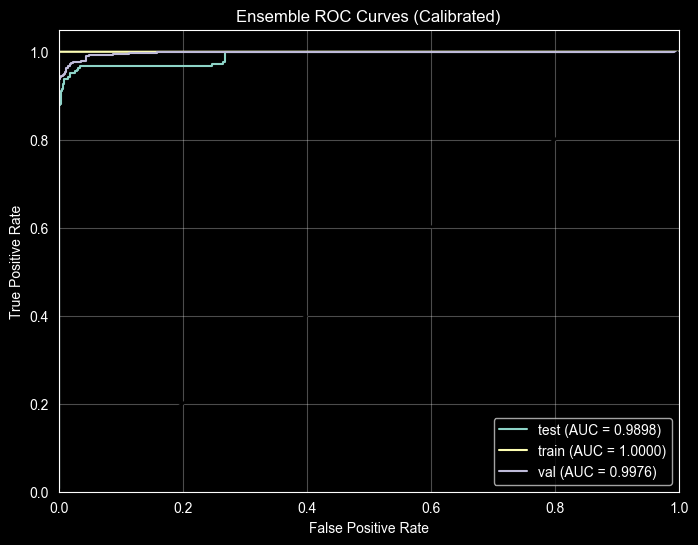

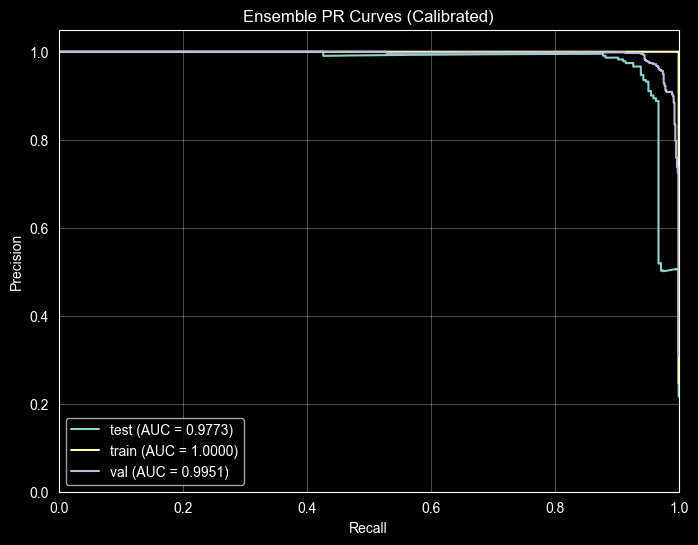

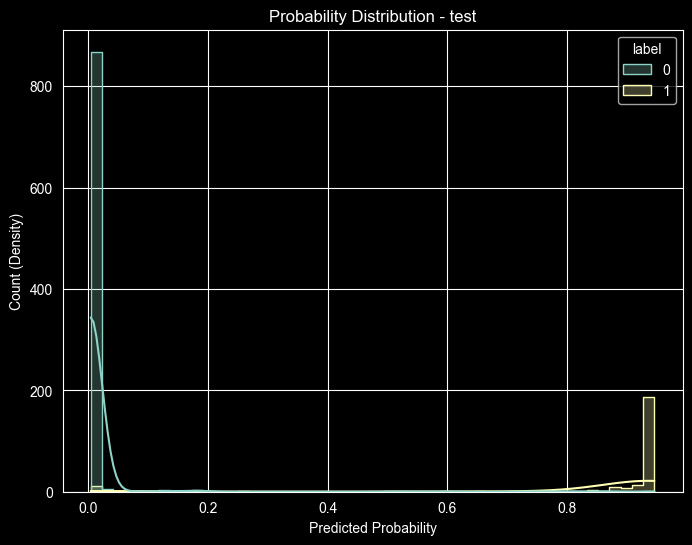

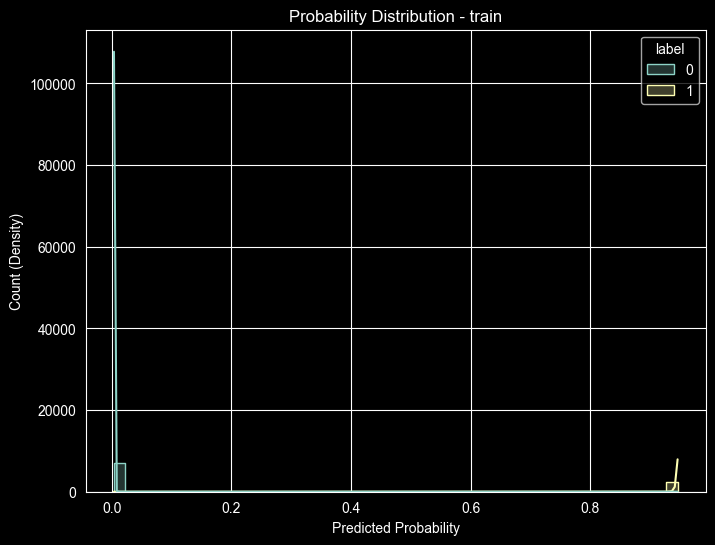

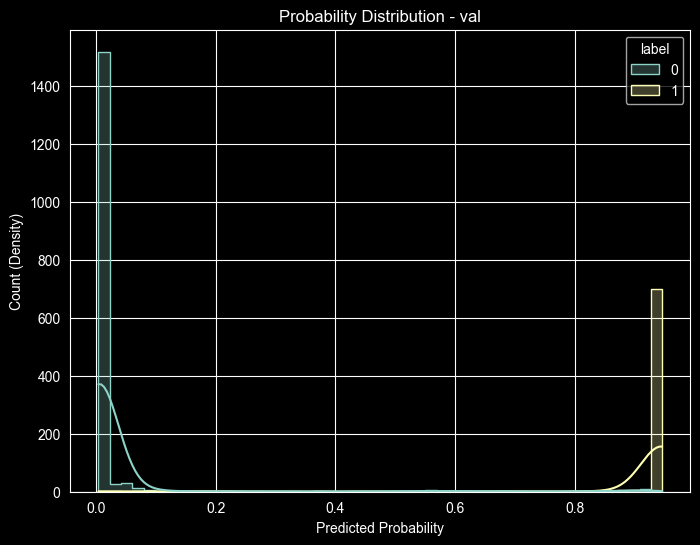

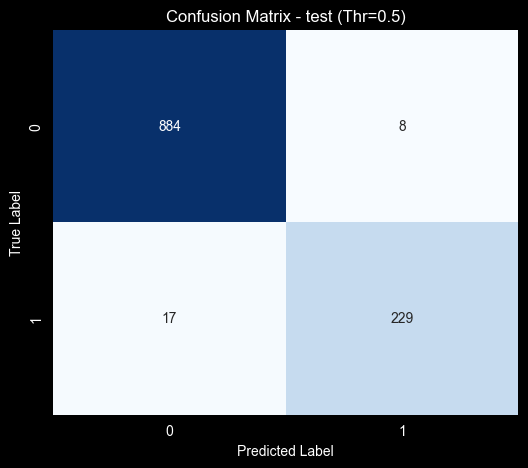

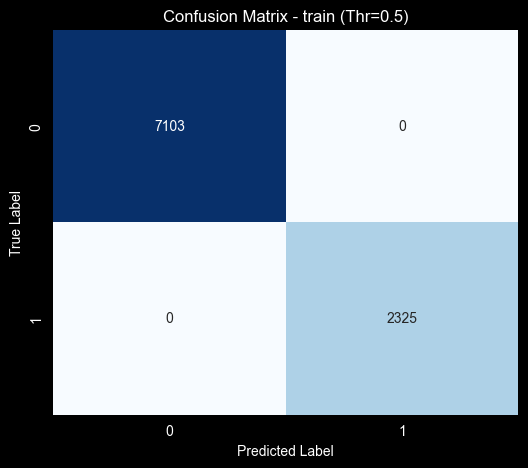

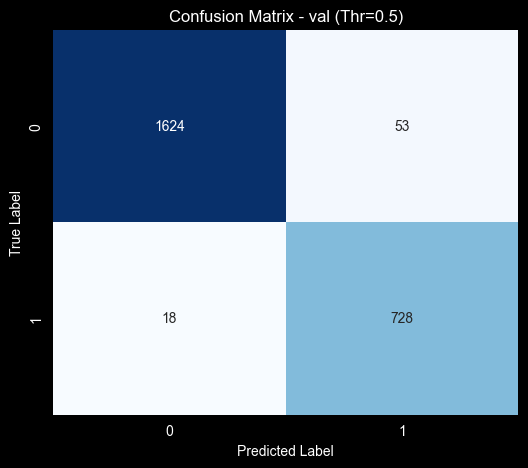

In [6]:
print("\n--- Generating Plots for Ensemble ---")
plot_roc_curves(df_preds, prob_col="p_calib", title="Ensemble ROC Curves (Calibrated)")
plot_pr_curves(df_preds, prob_col="p_calib", title="Ensemble PR Curves (Calibrated)")
plot_probability_distributions(df_preds, prob_col="p_calib")
plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=0.5)

In [7]:
# 6. Dataset Distribution Check
print("\n--- Dataset Distribution Across Splits ---")
dist_table = df_all.groupby(["dataset", "split"]).size().unstack(fill_value=0)
print(dist_table)
pct_table = dist_table.div(dist_table.sum(axis=1), axis=0) * 100
print("\n--- Percentage Distribution ---")
print(pct_table.round(2))
if (dist_table == 0).any().any(): print("\nWARNING: Some splits are empty for a dataset!")
else: print("\nCONFIRMED: Both datasets are present in all splits.")


--- Dataset Distribution Across Splits ---
split    test  train   val
dataset                   
iscx      337   3614   931
vnat      801   5814  1492

--- Percentage Distribution ---
split    test  train    val
dataset                    
iscx     6.90  74.03  19.07
vnat     9.88  71.72  18.40

CONFIRMED: Both datasets are present in all splits.
